In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, root_mean_squared_error, roc_curve, auc,  classification_report, precision_recall_curve, ConfusionMatrixDisplay, PrecisionRecallDisplay
import seaborn as sns
import kagglehub
from datetime import datetime

2025-12-17 15:25:18.772973: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-17 15:25:19.005955: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766013919.078156  108164 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766013919.100788  108164 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766013919.272960  108164 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

/mnt/c/Users/flope/Documents/CSE176ML/CSE176MLProject/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Classification with Tensorflow Decision Forest

## Download and store data into a dataframe 

In [2]:
# Download latest version
path = kagglehub.dataset_download("eshummalik/securepay-credit-card-fraud-detection-data")

print("Path to dataset files:", path)

Path to dataset files: /home/flopez0294/.cache/kagglehub/datasets/eshummalik/securepay-credit-card-fraud-detection-data/versions/1


In [3]:
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
dfSize = np.shape(df)
print(dfSize)
n = dfSize[0]
col = dfSize[1]

(284807, 31)


## Preproccessing

In [5]:
# check for NA values
print(df.isna().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


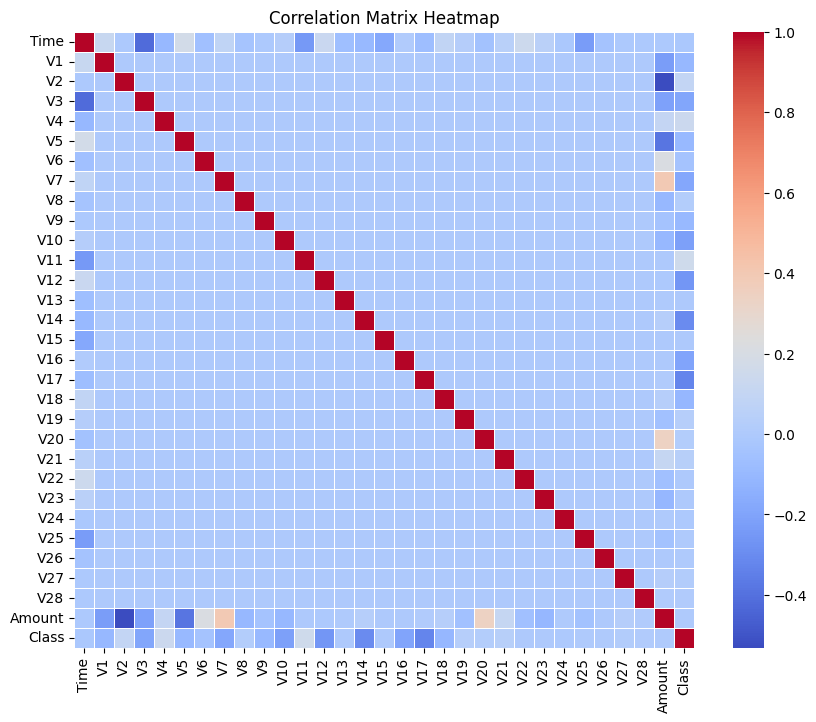

In [7]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=.5, )
plt.title('Correlation Matrix Heatmap')
plt.show()

['Amount', 'V28', 'V27', 'V26', 'V25', 'V24', 'V23', 'V22', 'V21', 'V20', 'V19', 'V18', 'V17', 'V16', 'V15', 'V14', 'V13', 'V12', 'V11', 'V10', 'V9', 'V8', 'V7', 'V6', 'V5', 'V4', 'V3', 'V2', 'V1', 'Time']


/tmp/ipykernel_108164/279521226.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[idx, jdx].boxplot([fea_class0, fea_class1], labels=['Not Fraud', 'Fraud'])
/tmp/ipykernel_108164/279521226.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[idx, jdx].boxplot([fea_class0, fea_class1], labels=['Not Fraud', 'Fraud'])
/tmp/ipykernel_108164/279521226.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[idx, jdx].boxplot([fea_class0, fea_class1], labels=['Not Fraud', 'Fraud'])
/tmp/ipykernel_108164/279521226.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_label

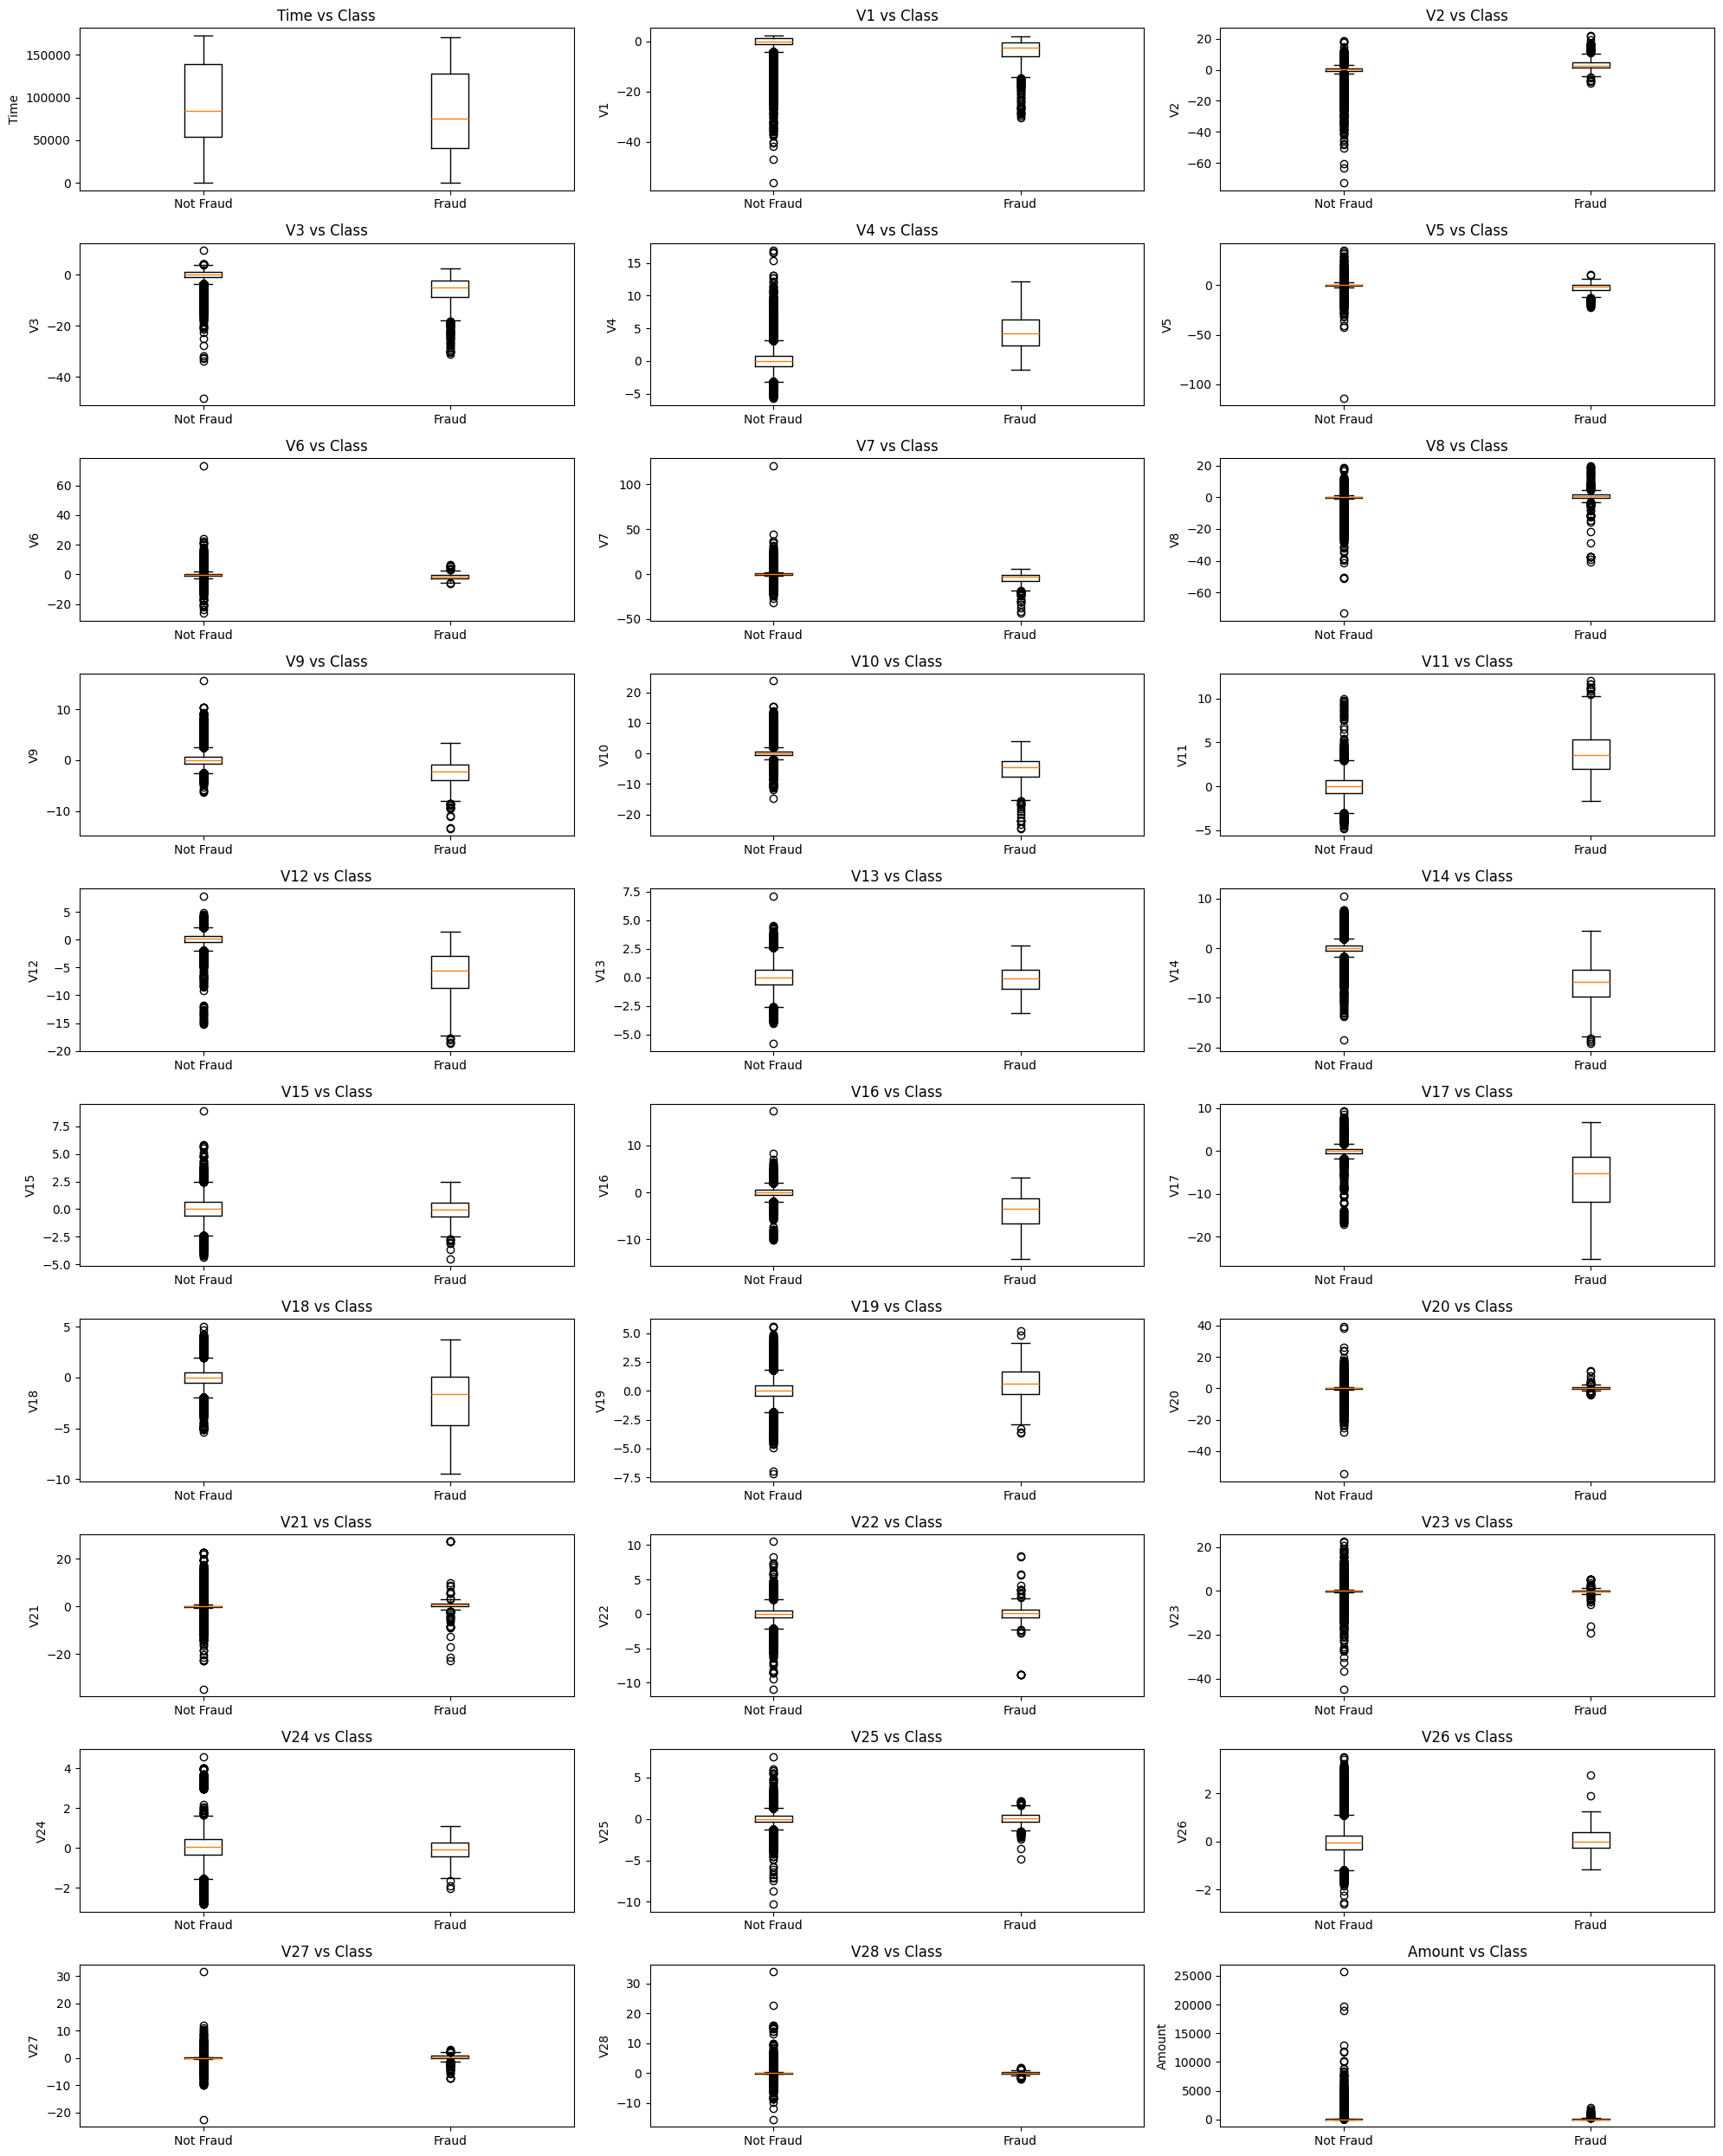

In [8]:
features = list(df.columns.drop('Class'))[::-1]
print(features)
fig, axs = plt.subplots(10, 3, figsize=(20,25))

for idx, ax in enumerate(axs):
    # Create two groups: V17 for class 0 and class 1
    for jdx, jx in enumerate(ax):
        fea = features.pop()
        fea_class0 = df[df['Class'] == 0][fea]
        fea_class1 = df[df['Class'] == 1][fea]
        axs[idx, jdx].boxplot([fea_class0, fea_class1], labels=['Not Fraud', 'Fraud'])
        axs[idx, jdx].set_ylabel(fea)
        axs[idx, jdx].set_title(f'{fea} vs Class')

plt.tight_layout()
plt.show()

'V12', 'V17', 'V4', 'V14', 'V10', 'V6', 'Time' - RandomForest best forward 7

'V14', 'V12', 'V4', 'V22', 'V1', 'V16', 'V3' - logistic Regression best forward 7

Notice from the graphs that the fraud class data is more likely to be compacted then the Not Fraud class
- Time doesn't seem to matter since they basically have the same spread for both classes
- seems like The amound spent is relatively small for the Fraud class when compared to the Not Fraud.

0         green
1         green
2         green
3         green
4         green
          ...  
284802    green
284803    green
284804    green
284805    green
284806    green
Name: Class, Length: 284807, dtype: object


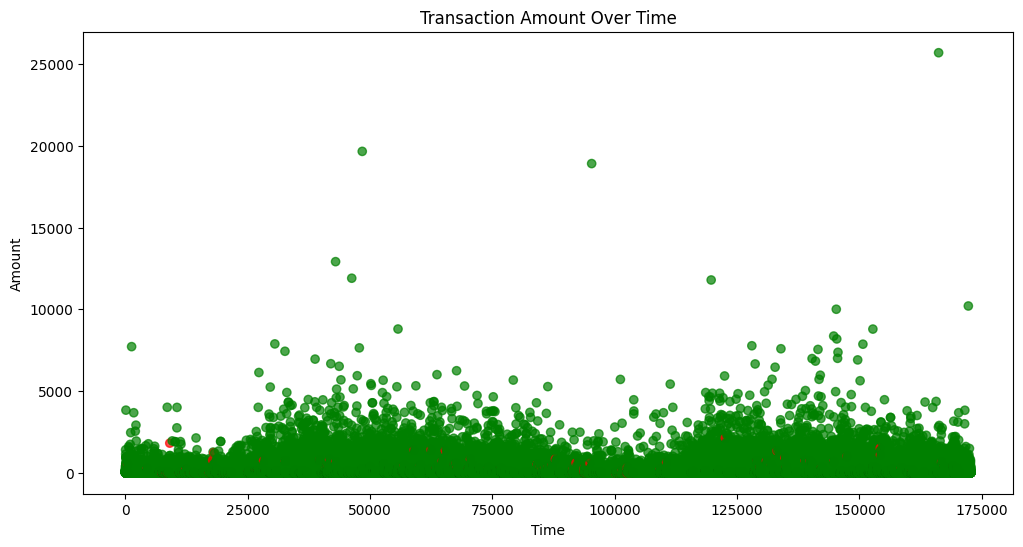

In [9]:
plt.figure(figsize=(12,6))
colors = df['Class'].map({0:'green', 1:'red'})
print(colors)
plt.scatter(df["Time"], df["Amount"], alpha=0.7, c=colors)
plt.title("Transaction Amount Over Time")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.show()




# Train First Model

In [88]:
df.head()
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['Class']), df['Class'], test_size = 0.2, random_state=67)
print(np.shape(x_train))
print(np.shape(x_test))


# convert to tensorflow datasets
x_train['Class'] = y_train
x_test['Class'] = y_test



train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(x_train, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(x_test, label="Class", task=tfdf.keras.Task.CLASSIFICATION)

(227845, 30)
(56962, 30)


In [89]:
# Specify the model.
model = tfdf.keras.RandomForestModel(verbose=2, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67)

# Train the model.
model.fit(train_ds)

Use 12 thread(s) for training
Use /tmp/tmpfg2ko_v0 as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'Time': <tf.Tensor 'data:0' shape=(None,) dtype=float64>, 'V1': <tf.Tensor 'data_1:0' shape=(None,) dtype=float64>, 'V2': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'V3': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'V4': <tf.Tensor 'data_4:0' shape=(None,) dtype=float64>, 'V5': <tf.Tensor 'data_5:0' shape=(None,) dtype=float64>, 'V6': <tf.Tensor 'data_6:0' shape=(None,) dtype=float64>, 'V7': <tf.Tensor 'data_7:0' shape=(None,) dtype=float64>, 'V8': <tf.Tensor 'data_8:0' shape=(None,) dtype=float64>, 'V9': <tf.Tensor 'data_9:0' shape=(None,) dtype=float64>, 'V10': <tf.Tensor 'data_10:0' shape=(None,) dtype=float64>, 'V11': <tf.Tensor 'data_11:0' shape=(None,) dtype=float64>, 'V12': <tf.Tensor 'data_12:0' shape=(None,) dtype=float64>, 'V13': <tf.Tensor 'data_13:0' shape=(None,) dtype=float64>, 'V14': <tf.Tensor 'data_14:0' sh

In [90]:
model.summary()
model.compile(metrics=['accuracy'])
evaluation = model.evaluate(test_ds, return_dict=True, use_multiprocessing=True)
preds = model.predict(test_ds)

print(f"The RMSE of this testing evaluation is: {evaluation}")
inspector = model.make_inspector()
print(inspector.evaluation())
print(inspector.variable_importances())


Model: "random_forest_model_479"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.207636 ################
    2.    "V17"  0.201696 ###############
    3.     "V4"  0.165228 #########
    4.    "V10"  0.148817 #######
    5.    "V12"  0.146009 ######
    6.    "V11"  0.128151 ###
    7.    "V16"  0.122060 ##
    8.     "V7"  0.119454 ##
    9.     "V3"  0.118151 ##
   10. "Amount"  0.113560 #
   11.    "V19"  0.112235 #
   12.     "V8"  0.109795 #
   

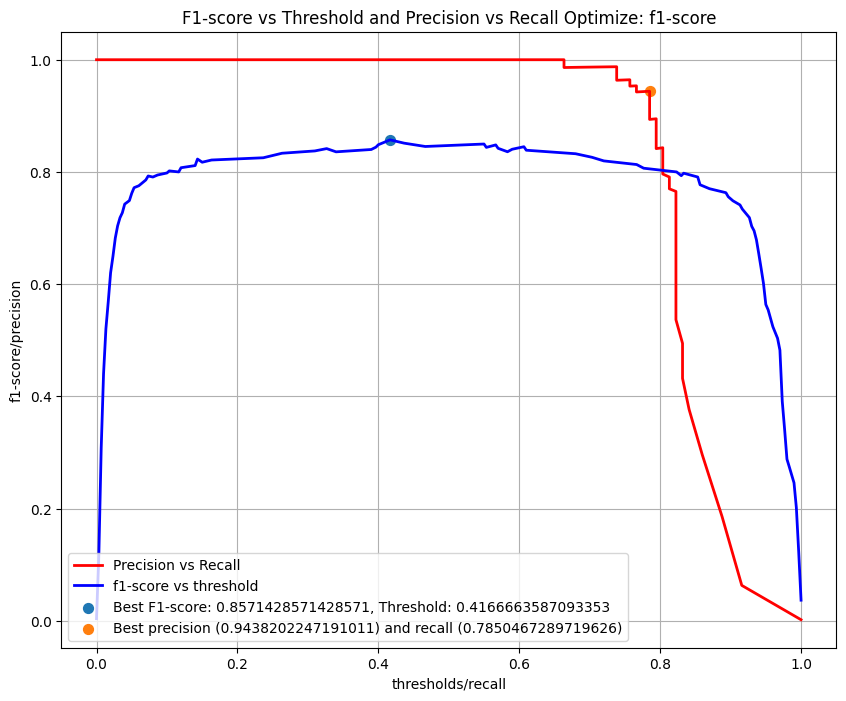

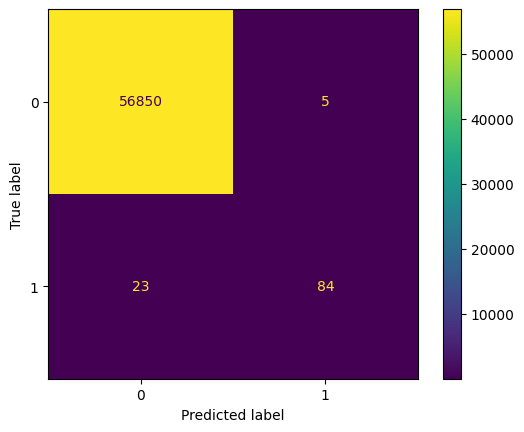

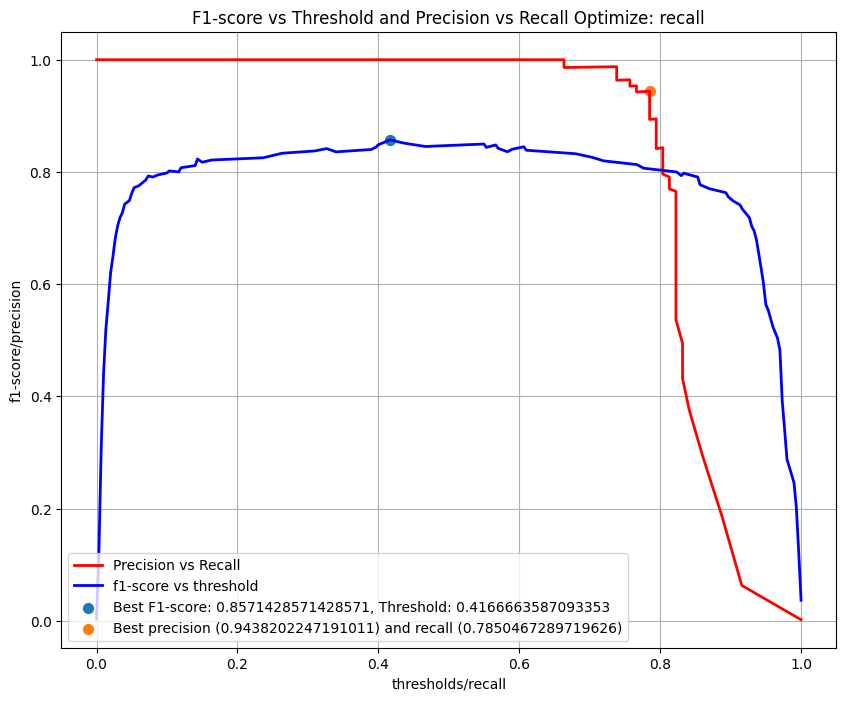

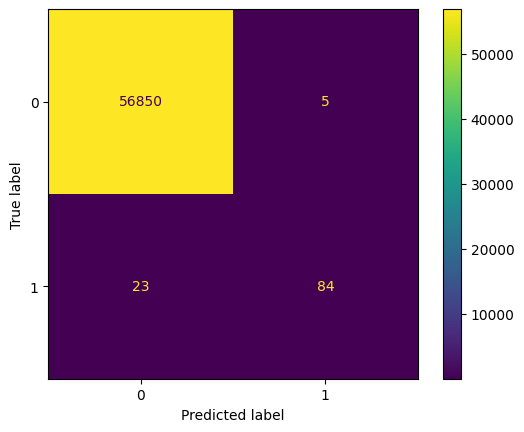

In [91]:
def print_graphs(y_test, preds, opt = 'f1-score', ret = False):
    precision, recall, thresholds = precision_recall_curve(y_test, preds)  
    f1_scores = 2 * ((precision[:-1] * recall[:-1])/(precision[:-1] + recall[:-1]))
    max_idx = 0
    if opt.lower() == 'recall':
        max_idx = np.argmax(recall[:-1])
    if opt.lower() == 'precision':
        max_idx = np.argmax(precision[:-1])
    else:
        max_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[max_idx]
    best_threshold = thresholds[max_idx]
    best_precision = precision[max_idx]  
    best_recall = recall[max_idx]
    if ret:
        return (best_f1, best_threshold)
    # print(f"Best Precision: {best_precision}, Best_recall: {best_recall}")
    # print(f'Best F1_score: {best_f1}, Best Threshold: {best_threshold}')
    plt.figure(figsize=(10, 8))
    plt.plot(recall, precision, color='red', lw=2, label=f'Precision vs Recall')
    plt.plot(thresholds, f1_scores, color='blue', lw=2, label=f'f1-score vs threshold')
    plt.scatter(best_threshold, best_f1, s=50, marker='o', label=f'Best F1-score: {best_f1}, Threshold: {best_threshold}')
    plt.scatter(best_recall, best_precision, s=50, marker='o', label=f'Best precision ({best_precision}) and recall ({best_recall})')
    plt.xlabel('thresholds/recall')
    plt.ylabel('f1-score/precision')
    plt.title(f'F1-score vs Threshold and Precision vs Recall Optimize: {opt.lower()}')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()

    # confusion Matrix with best_threshold
    confusion_mat = confusion_matrix(y_test, (preds >= best_threshold).astype(int))
    disp = ConfusionMatrixDisplay(confusion_mat)
    disp.plot()

print_graphs(y_test, preds)
print_graphs(y_test, preds, 'recall')

In [92]:
print(inspector.variable_importances().keys())
print(inspector.variable_importances()['INV_MEAN_MIN_DEPTH'])
print(inspector.variable_importances()['SUM_SCORE'])
print(inspector.variable_importances()['NUM_AS_ROOT'])
print(inspector.variable_importances()['NUM_NODES'])

dict_keys(['INV_MEAN_MIN_DEPTH', 'SUM_SCORE', 'NUM_AS_ROOT', 'NUM_NODES'])
[("V14" (1; #7), 0.20763641635978794), ("V17" (1; #10), 0.2016957907511756), ("V4" (1; #24), 0.16522831534160803), ("V10" (1; #3), 0.14881693211311608), ("V12" (1; #5), 0.14600889265943076), ("V11" (1; #4), 0.1281513998950766), ("V16" (1; #9), 0.12205980629220027), ("V7" (1; #27), 0.1194539222630092), ("V3" (1; #23), 0.11815068536188351), ("Amount" (1; #0), 0.11355962313743521), ("V19" (1; #12), 0.11223544384097396), ("V8" (1; #28), 0.10979453763530585), ("V18" (1; #11), 0.10956138626668281), ("V20" (1; #14), 0.10930364442473633), ("V21" (1; #15), 0.10874117358070008), ("V9" (1; #29), 0.10863486373932887), ("V2" (1; #13), 0.1078148335561729), ("V23" (1; #17), 0.10732158054002469), ("V26" (1; #20), 0.1062494608881603), ("V5" (1; #25), 0.10579845595701994), ("V15" (1; #8), 0.10572217996281304), ("V27" (1; #21), 0.10567998021427352), ("V1" (1; #2), 0.10543946703858512), ("V28" (1; #22), 0.1053019860512151), ("V22" 

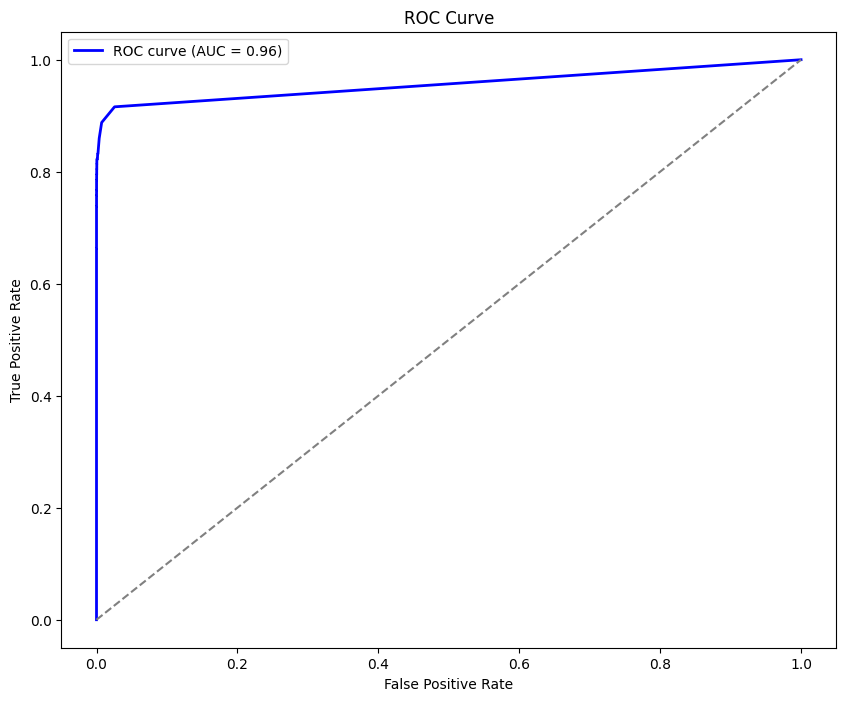

In [93]:
fpr, tpr, thresholds = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

Resolve hyper-parameter template "benchmark_rank1" to "benchmark_rank1@v1" -> {'winner_take_all': True, 'categorical_algorithm': 'RANDOM', 'split_axis': 'SPARSE_OBLIQUE', 'sparse_oblique_normalization': 'MIN_MAX', 'sparse_oblique_num_projections_exponent': 1.0}.
Use 12 thread(s) for training
Use /tmp/tmpwnmi48ou as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'Time': <tf.Tensor 'data:0' shape=(None,) dtype=float64>, 'V1': <tf.Tensor 'data_1:0' shape=(None,) dtype=float64>, 'V2': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'V3': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'V4': <tf.Tensor 'data_4:0' shape=(None,) dtype=float64>, 'V5': <tf.Tensor 'data_5:0' shape=(None,) dtype=float64>, 'V6': <tf.Tensor 'data_6:0' shape=(None,) dtype=float64>, 'V7': <tf.Tensor 'data_7:0' shape=(None,) dtype=float64>, 'V8': <tf.Tensor 'data_8:0' shape=(None,) dtype=float64>, 'V9': <tf.Tensor 'data_9:0' shape=(None,) dtype=float64>, 'V10': <t

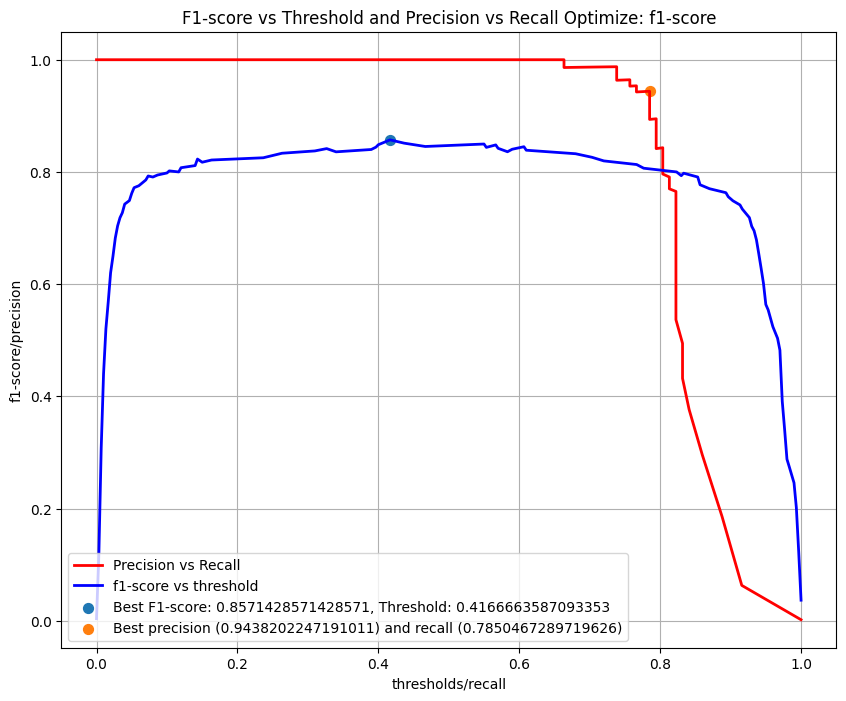

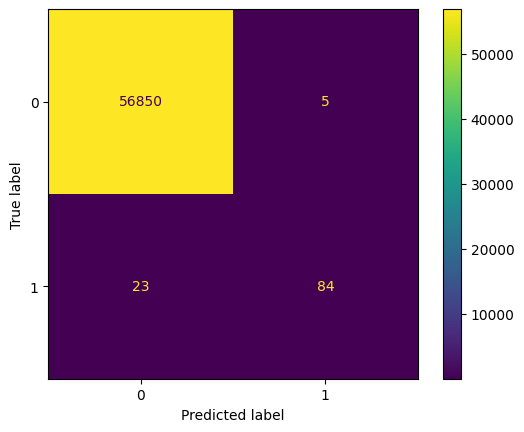

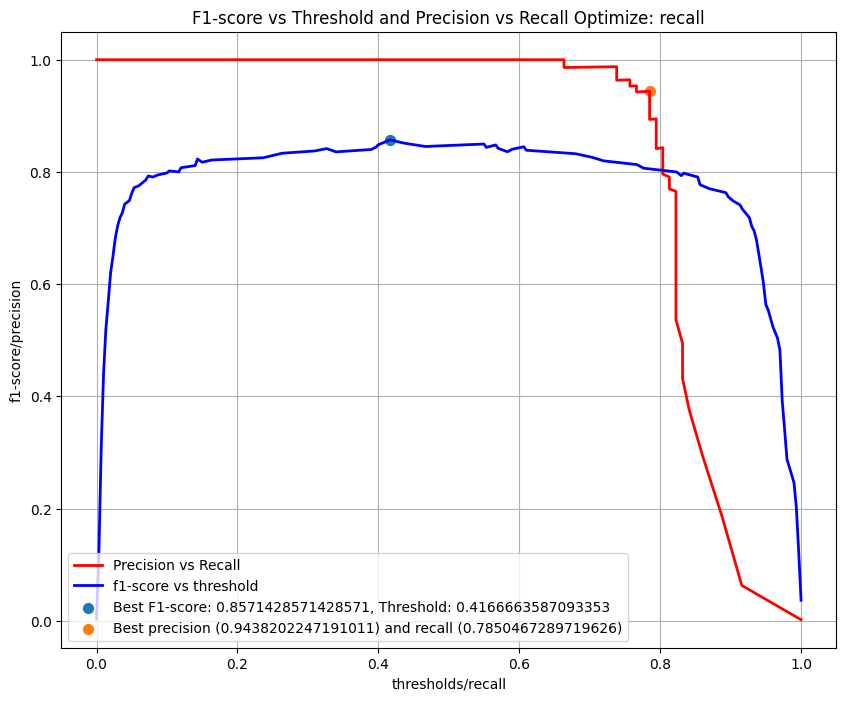

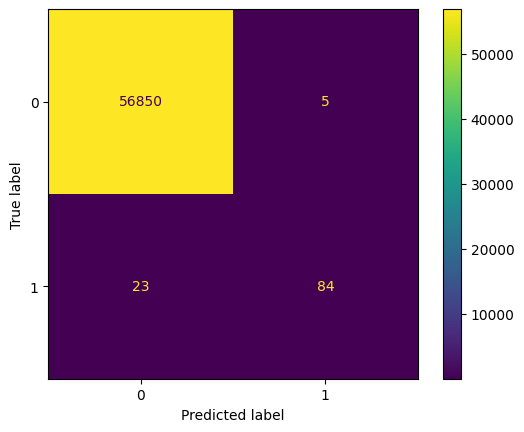

In [ ]:
model_hypetemp = tfdf.keras.RandomForestModel(verbose=2, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67, hyperparameter_template='benchmark_rank1')

# Train the model.
model_hypetemp.fit(train_ds)
model_hypetemp.summary()
model_hypetemp.compile(metrics=['accuracy'])
evaluation = model.evaluate(test_ds, return_dict=True, use_multiprocessing=True)
preds = model.predict(test_ds)

print_graphs(y_test, preds)


In [99]:
f1_testing = []
sub_x_train, sub_x_val, sub_y_train, sub_y_val = train_test_split(x_train, y_train, test_size=.2, random_state=67)
sub_train_df = sub_x_train.copy()
sub_train_df['Class'] = sub_y_train.astype(int)
sub_val_df = sub_x_val.copy()
sub_val_df['Class'] = sub_y_val.astype(int)

sub_train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(sub_train_df, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
sub_val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(sub_val_df, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
for i in np.arange(500, 1501, 200):   
    model_hype = tfdf.keras.RandomForestModel(verbose=0, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67, num_trees=int(i))

    # Train the model.
    model_hype.fit(sub_train_ds)
    model_hype.summary()
    model_hype.compile(metrics=['accuracy'])
    preds = model_hype.predict(sub_val_ds)
    print(f'Number of trees: {i}')
    f1_testing.append(print_graphs(sub_y_val, preds, ret=True))

I0000 00:00:1766024599.203609  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766024599.203644  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766024599.203652  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766024599.203724  108164 kernel.cc:401] Number of batches: 183
I0000 00:00:1766024599.203727  108164 kernel.cc:402] Number of examples: 182276
I0000 00:00:1766024599.225943  108164 kernel.cc:802] Training dataset:
Number of records: 182276
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

Model: "random_forest_model_498"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.222745 ################
    2.    "V17"  0.203425 #############
    3.     "V4"  0.168072 ########
    4.    "V10"  0.154877 ######
    5.    "V12"  0.143786 #####
    6.    "V11"  0.131118 ###
    7.    "V16"  0.128619 ###
    8.     "V3"  0.124690 ##
    9.    "V19"  0.121349 ##
   10.     "V7"  0.117775 #
   11. "Amount"  0.117695 #
   12.     "V8"  0.113968 #
   13. 

I0000 00:00:1766024616.678839  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766024616.678878  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766024616.678886  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766024616.678983  108164 kernel.cc:401] Number of batches: 183
I0000 00:00:1766024616.678989  108164 kernel.cc:402] Number of examples: 182276
I0000 00:00:1766024616.702634  108164 kernel.cc:802] Training dataset:
Number of records: 182276
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

Model: "random_forest_model_499"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________


I0000 00:00:1766024637.543376  108164 decision_forest.cc:808] Model loaded with 700 root(s), 114864 node(s), and 30 input feature(s).
I0000 00:00:1766024637.543455  108164 abstract_model.cc:1439] Engine "RandomForestOptPred" built
2025-12-17 18:23:57.543474: I tensorflow_decision_forests/tensorflow/ops/inference/kernel.cc:1035] Use fast generic engine


...

Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.219347 ################
    2.    "V17"  0.200756 #############
    3.     "V4"  0.168680 ########
    4.    "V10"  0.155547 ######
    5.    "V12"  0.144096 #####
    6.    "V11"  0.133214 ###
    7.    "V16"  0.128897 ###
    8.     "V3"  0.123710 ##
    9.    "V19"  0.120564 ##
   10.     "V7"  0.117179 #
   11. "Amount"  0.116386 #
   12.    "V18"  0.114345 #
   13.     "V9"  0.114056 #
   14.     "V8"  0.113140 
   15.     "V5"  0.111323 
   16.    "V21"  0.111306 
   17.     "V2"  0.111207 
   18.    "V20"  0.111038 
   19.    "V28"  0.110933 
   20.    "V26"  0.110932 
   21.    "V27"  0.110074 
   22.    "V23"  0.109466 
   23.     "V6"  0.109244 
   24.     "V1"  0.108799 
   25.   

I0000 00:00:1766024746.974322  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766024746.974355  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766024746.974362  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766024746.974434  108164 kernel.cc:401] Number of batches: 183
I0000 00:00:1766024746.974438  108164 kernel.cc:402] Number of examples: 182276
I0000 00:00:1766024746.997089  108164 kernel.cc:802] Training dataset:
Number of records: 182276
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

Model: "random_forest_model_503"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________


I0000 00:00:1766024790.144657  108164 decision_forest.cc:808] Model loaded with 1500 root(s), 246692 node(s), and 30 input feature(s).
I0000 00:00:1766024790.144712  108164 abstract_model.cc:1439] Engine "RandomForestOptPred" built
2025-12-17 18:26:30.144729: I tensorflow_decision_forests/tensorflow/ops/inference/kernel.cc:1035] Use fast generic engine


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.220476 ################
    2.    "V17"  0.201442 #############
    3.     "V4"  0.168693 ########
    4.    "V10"  0.155836 ######
    5.    "V12"  0.144176 #####
    6.    "V11"  0.132522 ###
    7.    "V16"  0.128869 ###
    8.     "V3"  0.123902 ##
    9.    "V19"  0.121044 ##
   10.     "V7"  0.117487 #
   11. "Amount"  0.116319 #
   12.    "V18"  0.114578 #
   13.     "V9"  0.114385 #
   14.     "V8"  0.113436 #
   15.    "V21"  0.111628 
   16.     "V5"  0.111541 
   17.     "V2"  0.111256 
   18.    "V20"  0.111096 
   19.    "V26"  0.110990 
   20.    "V28"  0.110974 
   21.    "V27"  0.109979 
   22.    "V23"  0.109462 
   23.     "V6"  0.109364 
   24.     "V1"  0.108994 
   25.  

In [100]:
print(f1_testing)

[(np.float64(0.860759493670886), np.float32(0.49400064)), (np.float64(0.860759493670886), np.float32(0.48428655)), (np.float64(0.860759493670886), np.float32(0.4822235)), (np.float64(0.860759493670886), np.float32(0.4954541)), (np.float64(0.860759493670886), np.float32(0.4992291)), (np.float64(0.860759493670886), np.float32(0.50200325))]


Use /tmp/tmpyqr1497i as temporary training directory
Reading training dataset...
Training dataset read in 0:00:01.554134. Found 227845 examples.
Training model...


I0000 00:00:1766025241.000788  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766025241.000835  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766025241.000843  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766025241.000944  108164 kernel.cc:401] Number of batches: 228
I0000 00:00:1766025241.000948  108164 kernel.cc:402] Number of examples: 227845
I0000 00:00:1766025241.028589  108164 kernel.cc:802] Training dataset:
Number of records: 227845
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

Model trained in 0:00:20.311838
Compiling model...
Model compiled.
Model: "random_forest_model_505"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.215171 ################
    2.    "V17"  0.194330 #############
    3.     "V4"  0.164115 ########
    4.    "V10"  0.149853 ######
    5.    "V12"  0.146277 ######
    6.    "V11"  0.126940 ###
    7.    "V16"  0.123288 ##
    8.     "V3"  0.118078 ##
    9.     "V7"  0.117456 ##
   10.    "V19"  0.11372

I0000 00:00:1766025261.303277  108164 decision_forest.cc:808] Model loaded with 500 root(s), 100738 node(s), and 30 input feature(s).
I0000 00:00:1766025261.303333  108164 abstract_model.cc:1439] Engine "RandomForestOptPred" built
2025-12-17 18:34:21.303351: I tensorflow_decision_forests/tensorflow/ops/inference/kernel.cc:1035] Use fast generic engine


57/57 [==============================] - 1s 18ms/step


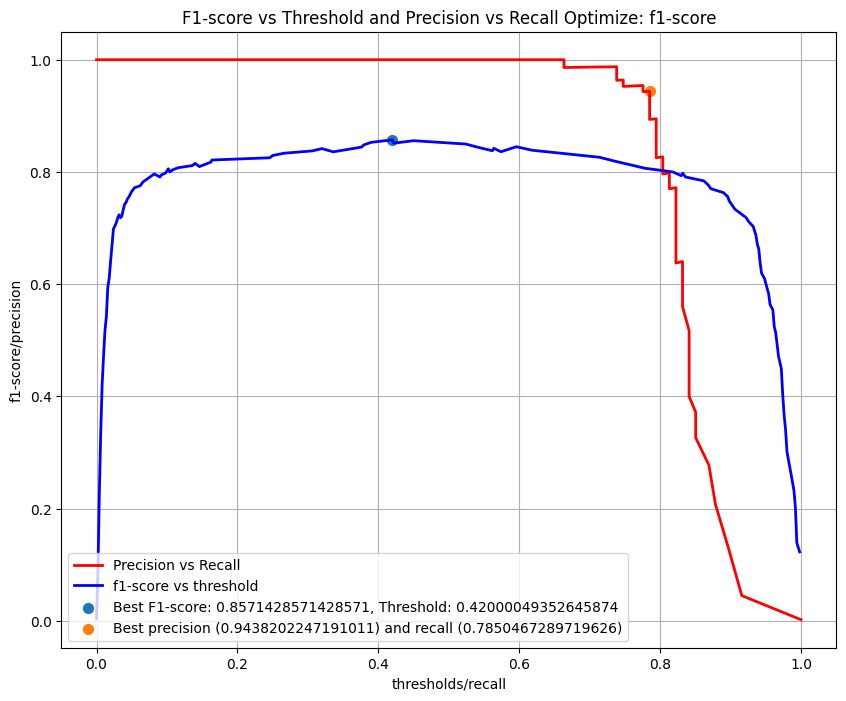

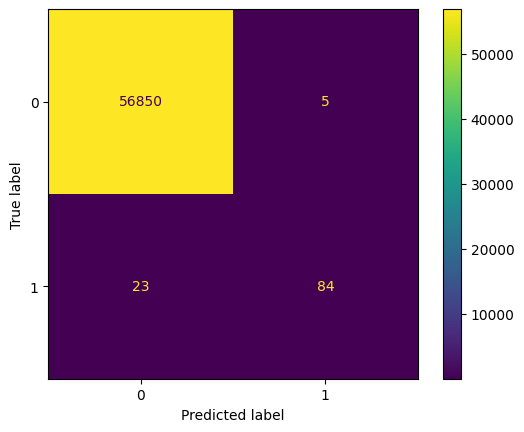

In [102]:
model500 = tfdf.keras.RandomForestModel(verbose=1, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67, num_trees=500)

    # Train the model.
model500.fit(train_ds)
model500.summary()
model500.compile(metrics=['accuracy'])
preds = model500.predict(test_ds)
print_graphs(y_test, preds)

In [103]:
f1_testing = []
sub_x_train, sub_x_val, sub_y_train, sub_y_val = train_test_split(x_train, y_train, test_size=.2, random_state=67)
sub_train_df = sub_x_train.copy()
sub_train_df['Class'] = sub_y_train.astype(int)
sub_val_df = sub_x_val.copy()
sub_val_df['Class'] = sub_y_val.astype(int)

sub_train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(sub_train_df, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
sub_val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(sub_val_df, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
for i in np.arange(10, 21, 2):   
    model_hype = tfdf.keras.RandomForestModel(verbose=0, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67, max_depth=int(i))

    # Train the model.
    model_hype.fit(sub_train_ds)
    model_hype.summary()
    model_hype.compile(metrics=['accuracy'])
    preds = model_hype.predict(sub_val_ds)
    print(f'Number of trees: {i}')
    f1_testing.append(print_graphs(sub_y_val, preds, ret=True))

I0000 00:00:1766025583.884394  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766025583.884445  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766025583.884453  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766025583.884567  108164 kernel.cc:401] Number of batches: 183
I0000 00:00:1766025583.884571  108164 kernel.cc:402] Number of examples: 182276
I0000 00:00:1766025583.909120  108164 kernel.cc:802] Training dataset:
Number of records: 182276
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

Model: "random_forest_model_506"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.230951 ################
    2.    "V17"  0.215552 #############
    3.    "V10"  0.184860 ########
    4.     "V4"  0.176786 #######
    5.    "V12"  0.165511 #####
    6.    "V11"  0.154107 ####
    7.    "V16"  0.149732 ###
    8.     "V3"  0.144879 ##
    9.     "V7"  0.140717 ##
   10.    "V19"  0.138046 #
   11.     "V9"  0.136686 #
   12. "Amount"  0.136234 #
   13

I0000 00:00:1766025593.605640  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766025593.605677  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766025593.605686  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766025593.605764  108164 kernel.cc:401] Number of batches: 183
I0000 00:00:1766025593.605769  108164 kernel.cc:402] Number of examples: 182276
I0000 00:00:1766025593.634302  108164 kernel.cc:802] Training dataset:
Number of records: 182276
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

Model: "random_forest_model_507"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.222514 ################
    2.    "V17"  0.208360 #############
    3.     "V4"  0.172852 ########
    4.    "V10"  0.171597 ########
    5.    "V12"  0.151610 #####
    6.    "V11"  0.143822 ####
    7.    "V16"  0.139002 ###
    8.     "V3"  0.133014 ##
    9.    "V19"  0.128230 #
   10.     "V7"  0.128161 #
   11. "Amount"  0.125857 #
   12.     "V9"  0.123666 #
   13

I0000 00:00:1766025604.169535  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766025604.169570  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766025604.169579  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766025604.169666  108164 kernel.cc:401] Number of batches: 183
I0000 00:00:1766025604.169671  108164 kernel.cc:402] Number of examples: 182276
I0000 00:00:1766025604.193955  108164 kernel.cc:802] Training dataset:
Number of records: 182276
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

...

Model: "random_forest_model_510"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________


I0000 00:00:1766025634.424939  108164 decision_forest.cc:808] Model loaded with 300 root(s), 50018 node(s), and 30 input feature(s).
I0000 00:00:1766025634.424985  108164 abstract_model.cc:1439] Engine "RandomForestOptPred" built
2025-12-17 18:40:34.425000: I tensorflow_decision_forests/tensorflow/ops/inference/kernel.cc:1035] Use fast generic engine


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.219238 ################
    2.    "V17"  0.195961 ############
    3.     "V4"  0.166404 ########
    4.    "V10"  0.158177 #######
    5.    "V12"  0.141620 #####
    6.    "V11"  0.133036 ###
    7.    "V16"  0.128379 ###
    8.     "V3"  0.123052 ##
    9.    "V19"  0.119567 #
   10.     "V7"  0.117193 #
   11. "Amount"  0.117031 #
   12.    "V18"  0.113086 #
   13.     "V8"  0.112602 #
   14.     "V9"  0.112530 
   15.     "V5"  0.111242 
   16.    "V26"  0.110714 
   17.     "V2"  0.110279 
   18.    "V20"  0.110194 
   19.    "V21"  0.109742 
   20.    "V28"  0.109690 
   21.    "V27"  0.108899 
   22.    "V15"  0.108233 
   23.     "V1"  0.107853 
   24.     "V6"  0.107606 
   25.    

I0000 00:00:1766025636.257821  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766025636.257867  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766025636.257878  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766025636.257979  108164 kernel.cc:401] Number of batches: 183
I0000 00:00:1766025636.257985  108164 kernel.cc:402] Number of examples: 182276
I0000 00:00:1766025636.283871  108164 kernel.cc:802] Training dataset:
Number of records: 182276
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

Model: "random_forest_model_511"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.219007 ################
    2.    "V17"  0.195362 ############
    3.     "V4"  0.166695 ########
    4.    "V10"  0.157589 #######
    5.    "V12"  0.140892 #####
    6.    "V11"  0.132873 ###
    7.    "V16"  0.127872 ###
    8.     "V3"  0.122784 ##
    9.    "V19"  0.119206 #
   10.     "V7"  0.116903 #
   11. "Amount"  0.116653 #
   12.    "V18"  0.112837 #
   13.  

In [104]:
print(f1_testing)

[(np.float64(0.8658536585365854), np.float32(0.30333313)), (np.float64(0.860759493670886), np.float32(0.4866663)), (np.float64(0.8606060606060606), np.float32(0.28333315)), (np.float64(0.8606060606060606), np.float32(0.28333315)), (np.float64(0.860759493670886), np.float32(0.48999962)), (np.float64(0.860759493670886), np.float32(0.4999996))]


Use /tmp/tmpfp69jpn2 as temporary training directory
Reading training dataset...
Training dataset read in 0:00:01.525681. Found 227845 examples.
Training model...


I0000 00:00:1766025837.552357  108164 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766025837.552412  108164 kernel.cc:783] Collect training examples
I0000 00:00:1766025837.552421  108164 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766025837.552622  108164 kernel.cc:401] Number of batches: 228
I0000 00:00:1766025837.552629  108164 kernel.cc:402] Number of examples: 227845
I0000 00:00:1766025837.581889  108164 kernel.cc:802] Training dataset:
Number of records: 227845
Number of columns: 31

Number of columns by type:
	NUMERICAL: 30 (96.7742%)
	CATEGORICAL: 1 (3.22581%)

Columns:

NUMERICAL: 30 (96.7742%)
	0: "Amount" NUMERIC

Model trained in 0:00:10.787976
Compiling model...


I0000 00:00:1766025848.231001  261929 random_forest.cc:865] Train tree 300/300 accuracy:0.999552 logloss:0.00819897 [index:299 total:10.58s tree:0.31s]
I0000 00:00:1766025848.231198  261906 random_forest.cc:949] Final OOB metrics: accuracy:0.999552 logloss:0.00819897
I0000 00:00:1766025848.243934  261906 kernel.cc:926] Export model in log directory: /tmp/tmpfp69jpn2 with prefix 936cce3d67e84788
I0000 00:00:1766025848.260027  261906 kernel.cc:944] Save model in resources
I0000 00:00:1766025848.261595  108164 abstract_model.cc:921] Model self evaluation:
Number of predictions (without weights): 227845
Number of predictions (with weights): 227845
Task: CLASSIFICATION
Label: __LABEL

Accuracy: 0.999552  CI95[W][0.999472 0.999623]
LogLoss: : 0.00819897
ErrorRate: : 0.00044769

Default Accuracy: : 0.99831
Default LogLoss: : 0.0124743
Default ErrorRate: : 0.00168973

Confusion Table:
truth\prediction
        1    2
1  227442   18
2      84  301
Total: 227845


2025-12-17 18:44:08.273208: I te

Model compiled.
Model: "random_forest_model_512"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.224480 ################
    2.    "V17"  0.216507 ##############
    3.    "V10"  0.175108 ########
    4.     "V4"  0.174770 ########
    5.    "V12"  0.167165 ######
    6.    "V11"  0.152424 ####
    7.    "V16"  0.144474 ###
    8.     "V7"  0.141579 ##
    9.     "V3"  0.140625 ##
   10.     "V9"  0.134109 #
   11.    "V19"  0.131812 #
   12. "Amount

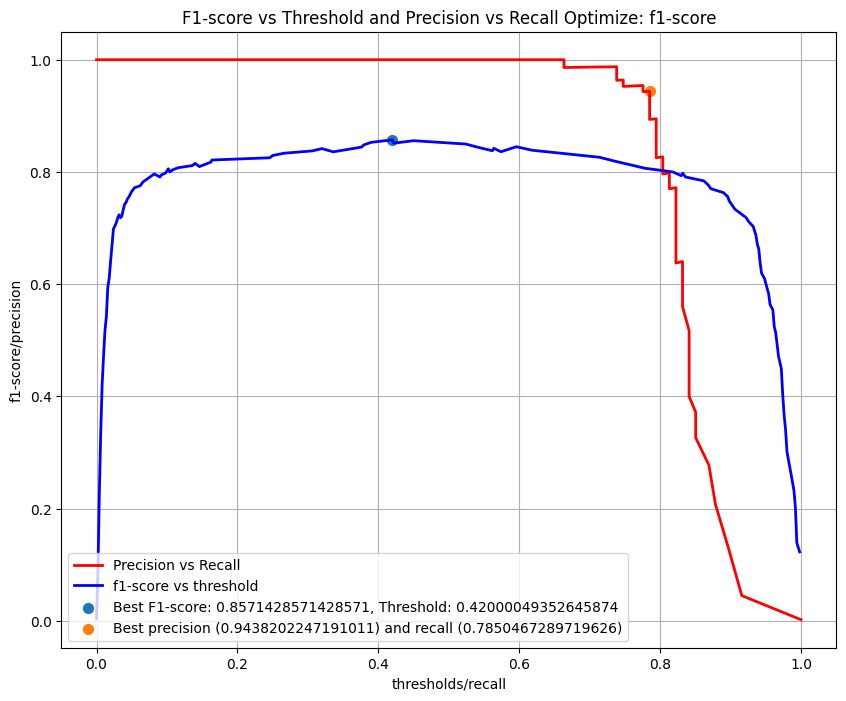

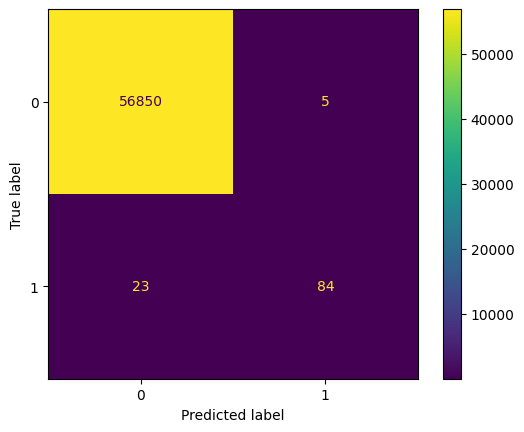

In [105]:
modeldepth = tfdf.keras.RandomForestModel(verbose=1, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67, max_depth=10)

    # Train the model.
modeldepth.fit(train_ds)
modeldepth.summary()
modeldepth.compile(metrics=['accuracy'])
preds = model500.predict(test_ds)
print_graphs(y_test, preds)

## From what we know ROC curves above the diagonal are really good classifiers and the closer we are to an AUC of 1 is so better.

Try best Subset Selection 

In [16]:
subset_selection = []
val_accuracy = []
best_thresholds = []
remain_feature = list(df.columns.drop('Class'))
best_val_accuracy = 0
n = len(remain_feature)
print(remain_feature)
for i in range(n):
    vals = {}
    vals_thresh = {}
    for feature in remain_feature:
        subset = subset_selection.copy() + [feature]
        sub_x_train, sub_x_val, sub_y_train, sub_y_val = train_test_split(x_train[subset], y_train, test_size=.2, random_state=376)
        sub_train_df = sub_x_train.copy()
        sub_train_df['Class'] = sub_y_train.astype(int)
        sub_val_df = sub_x_val.copy()
        sub_val_df['Class'] = sub_y_val.astype(int)

        sub_train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(sub_train_df, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
        sub_val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(sub_val_df, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
        
        model_sub = tfdf.keras.RandomForestModel(verbose=2, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67)
        model_sub.fit(sub_train_ds)

        model_sub.compile(metrics=['accuracy'])
        evaluation = model_sub.evaluate(sub_val_ds, return_dict=True, use_multiprocessing=True)
        preds = model_sub.predict(sub_val_ds)
        precision, recall, thresholds = precision_recall_curve(sub_y_val, preds) 
        f1_scores = 2 * ((precision[:-1] * recall[:-1])/(precision[:-1] + recall[:-1] + 1e-10))
        max_idx = np.argmax(f1_scores)
        best_f1 = f1_scores[max_idx]
        best_threshold = thresholds[max_idx]
        best_precision = precision[max_idx]  
        best_recall = recall[max_idx] 
        vals[feature] = best_f1
        vals_thresh[feature] = best_threshold
        
    best_sub_val = max(vals.values())
    best_thresh = max(vals_thresh.values())
    best_feature = [key for key, item in vals.items() if item == best_sub_val][0]
    subset_selection.append(best_feature)
    val_accuracy.append(best_sub_val)
    best_thresholds.append(best_thresh)
    remain_feature.remove(best_feature)
        
        
        


['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Use 12 thread(s) for training
Use /tmp/tmpnzseux7_ as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'Time': <tf.Tensor 'data:0' shape=(None,) dtype=float64>}
Label: Tensor("data_1:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'Time': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(None,) dtype=float32>)}
Training dataset read in 0:00:00.141870. Found 182276 examples.
Training model...
Model trained in 0:00:04.039046
Compiling model...
Model compiled.
46/46 [==============================] - 1s 12ms/step
Use 12 thread(s) for training
Use /tmp/tmpamu261am as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'V1': <tf.Tensor 'data:0

Training dataset read in 0:00:00.134895. Found 182276 examples.
Training model...
Model trained in 0:00:03.499397
Compiling model...
Model compiled.


46/46 [==============================] - 0s 8ms/step
Use 12 thread(s) for training
Use /tmp/tmp_e0o4htl as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'V4': <tf.Tensor 'data:0' shape=(None,) dtype=float64>}
Label: Tensor("data_1:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'V4': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(None,) dtype=float32>)}


Training dataset read in 0:00:00.158750. Found 182276 examples.
Training model...
Model trained in 0:00:03.164171
Compiling model...
Model compiled.


46/46 [==============================] - 0s 6ms/step
Use 12 thread(s) for training
Use /tmp/tmpo971o0il as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'V5': <tf.Tensor 'data:0' shape=(None,) dtype=float64>}
Label: Tensor("data_1:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'V5': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(None,) dtype=float32>)}
Training dataset read in 0:00:00.143533. Found 182276 examples.
Training model...
Model trained in 0:00:03.958942
Compiling model...
Model compiled.
46/46 [==============================] - 1s 11ms/step
Use 12 thread(s) for training
Use /tmp/tmpce7l5lu_ as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'V6': <tf.Tensor 'data:0' shape=(None,) dtype=float64>}
Label: Tensor("data_1:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'V6': SemanticTensor(semant

[np.float64(0.7044025156732724), np.float64(0.8129032257564703), np.float64(0.8378378377880661), np.float64(0.8624999999500078), np.float64(0.8789808916697472), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8846153845653928), np.float64(0.8789808916697472), np.float64(0.8846153845653928), np.float64(0.8789808916697472), np.float64(0.8846153845653928), np.float64(0.8789808916697472), np.float64(0.8774193547887283), np.float64(0.87179487174488), np.float64(0.8774193547887283), np.float64(0.8701298700799038), np.float64(0.8701298700799038), np.float64(0.8701298700799038), np.float64(0.8701298700799038)]
[np.float32(0.6533328), np.float32(0.5499

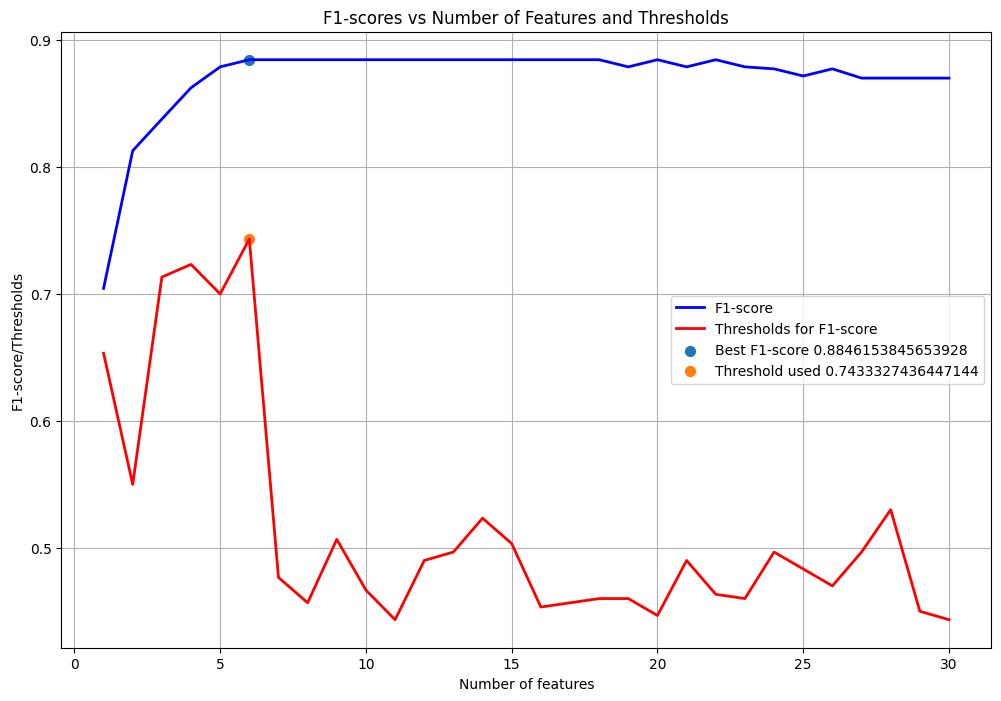

In [77]:
print(val_accuracy)
print(best_thresholds)
print(subset_selection)
best_score_idx = np.argmax(val_accuracy)
number_sub = [i+1 for i in range(len(val_accuracy))]
print(best_score_idx)
plt.figure(figsize=(12, 8))
plt.plot(number_sub, val_accuracy, lw=2, color='blue', label=f'F1-score')
plt.plot(number_sub, best_thresholds, lw=2, color='red', label=f'Thresholds for F1-score')
plt.scatter(best_score_idx +1, val_accuracy[best_score_idx], s=50, label=f'Best F1-score {val_accuracy[best_score_idx]}')
plt.scatter(best_score_idx + 1, best_thresholds[best_score_idx], s=50, label=f'Threshold used {best_thresholds[best_score_idx]}')
plt.xlabel('Number of features')
plt.ylabel('F1-score/Thresholds')
plt.title('F1-scores vs Number of Features and Thresholds')
plt.grid(True)
plt.legend()
plt.show()

Use 12 thread(s) for training
Use /tmp/tmpyaphlwlc as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'V17': <tf.Tensor 'data:0' shape=(None,) dtype=float64>, 'V12': <tf.Tensor 'data_1:0' shape=(None,) dtype=float64>, 'V4': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'V14': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'V10': <tf.Tensor 'data_4:0' shape=(None,) dtype=float64>, 'V21': <tf.Tensor 'data_5:0' shape=(None,) dtype=float64>}
Label: Tensor("data_6:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'V17': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(None,) dtype=float32>), 'V12': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_1:0' shape=(None,) dtype=float32>), 'V4': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_2:0' shape=(None,) dtype=float32>), 'V14': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, te

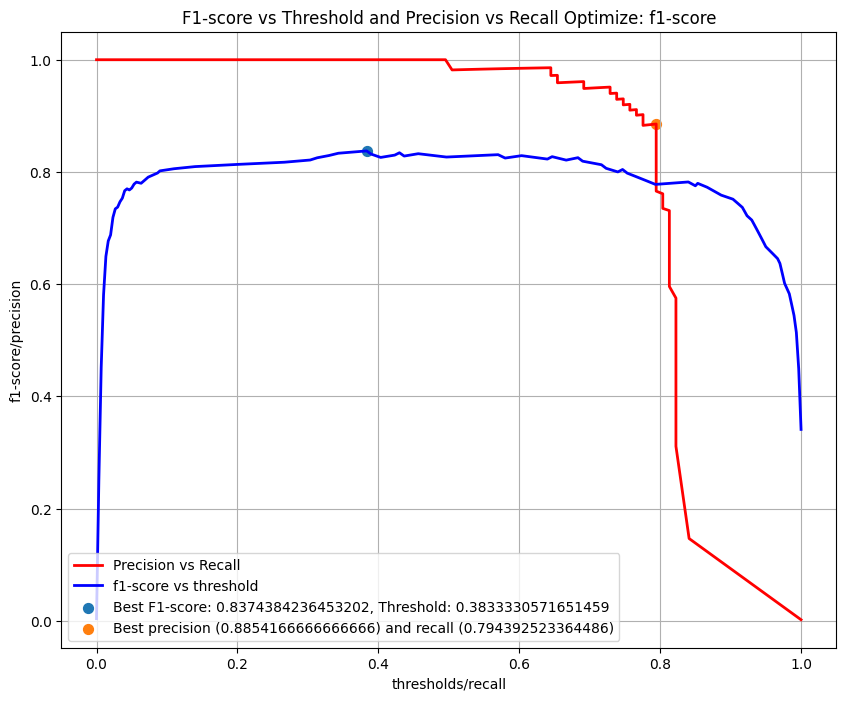

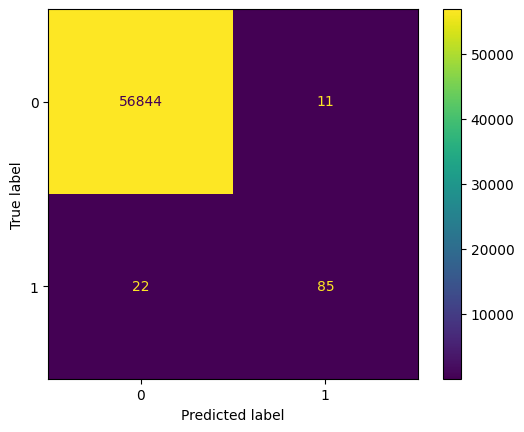

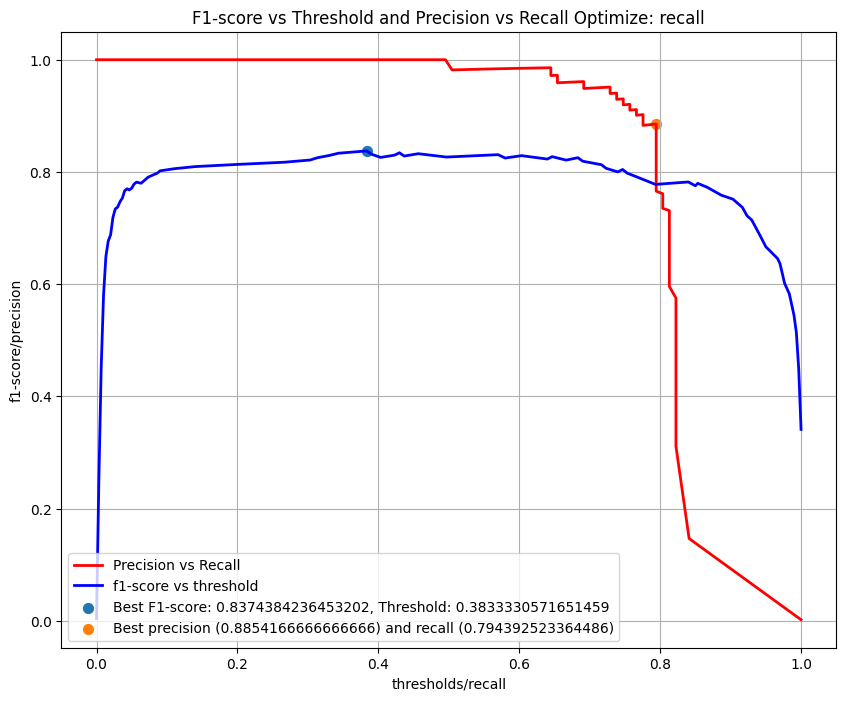

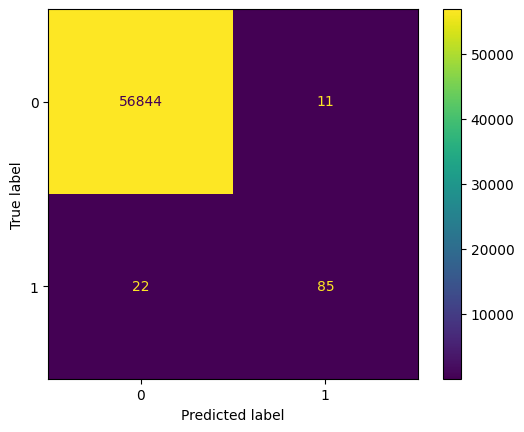

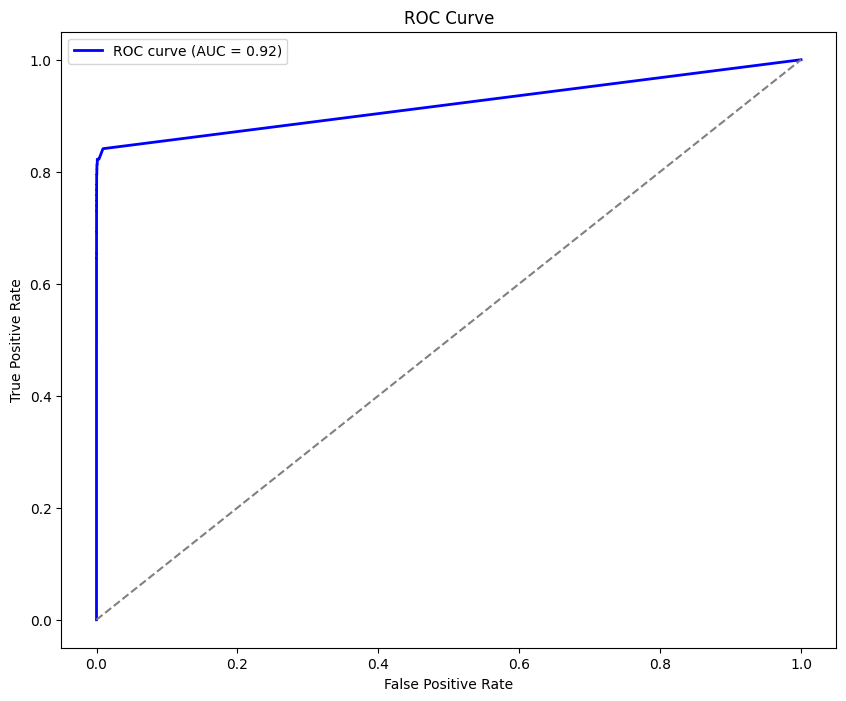

In [106]:
# So WE dont have to rerun the module above it took close to an hour the last time it was ran
# subset_selection = ['V12', 'V17', 'V4', 'V14', 'V10', 'V6', 'Time', 'V5', 'V2', 'V3', 'V8', 'V11', 'V20', 'V25', 'V16', 'V27', 'V13', 'V28', 'V15', 'V24', 'V7', 'V18', 'V1', 'Amount', 'V22', 'V19', 'V21', 'V23', 'V9', 'V26']
subset_selection = ['V17', 'V12', 'V4', 'V14', 'V10', 'V21', 'Time', 'V1', 'V2', 'V5', 'V3', 'V6', 'V16', 'V7', 'V24', 'V23', 'V11', 'Amount', 'V18', 'V13', 'V20', 'V28', 'V19', 'V15', 'V25', 'V22', 'V9', 'V26', 'V27', 'V8']
subList = subset_selection[0:best_score_idx+1]
one_x_train = x_train[subList].copy()
one_x_test = x_test[subList].copy()
one_x_train['Class'] = y_train.astype(int)
one_x_test['Class'] = y_test.astype(int)

one_train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(one_x_train, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
one_test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(one_x_test, label="Class", task=tfdf.keras.Task.CLASSIFICATION)

model_1 = tfdf.keras.RandomForestModel(verbose=2, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67, max_depth=10)
model_1.fit(one_train_ds)

preds_1 = model_1.predict(one_test_ds)

model_1.compile(metrics=['accuracy'])
evaluation = model_1.evaluate(one_test_ds, return_dict=True, use_multiprocessing=True)
print(evaluation)
print_graphs(y_test, preds_1)
print_graphs(y_test, preds_1, 'recall')


fpr, tpr, thresholds = roc_curve(y_test, preds_1)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()


## Try Gradient Boosted Trees

In [113]:
model_gradient = tfdf.keras.GradientBoostedTreesModel(task=tfdf.keras.Task.CLASSIFICATION, verbose=2, random_seed = 67, max_depth=10, early_stopping="NONE")
model_gradient.fit(train_ds)

Use 12 thread(s) for training
Use /tmp/tmpsatqewgg as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'Time': <tf.Tensor 'data:0' shape=(None,) dtype=float64>, 'V1': <tf.Tensor 'data_1:0' shape=(None,) dtype=float64>, 'V2': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'V3': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'V4': <tf.Tensor 'data_4:0' shape=(None,) dtype=float64>, 'V5': <tf.Tensor 'data_5:0' shape=(None,) dtype=float64>, 'V6': <tf.Tensor 'data_6:0' shape=(None,) dtype=float64>, 'V7': <tf.Tensor 'data_7:0' shape=(None,) dtype=float64>, 'V8': <tf.Tensor 'data_8:0' shape=(None,) dtype=float64>, 'V9': <tf.Tensor 'data_9:0' shape=(None,) dtype=float64>, 'V10': <tf.Tensor 'data_10:0' shape=(None,) dtype=float64>, 'V11': <tf.Tensor 'data_11:0' shape=(None,) dtype=float64>, 'V12': <tf.Tensor 'data_12:0' shape=(None,) dtype=float64>, 'V13': <tf.Tensor 'data_13:0' shape=(None,) dtype=float64>, 'V14': <tf.Tensor 'data_14:0' sh

W0000 00:00:1766026331.653333  108164 gradient_boosted_trees.cc:1873] "goss_alpha" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1766026331.653385  108164 gradient_boosted_trees.cc:1883] "goss_beta" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1766026331.653388  108164 gradient_boosted_trees.cc:1897] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Normalized tensor features:
 {'Time': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(None,) dtype=float32>), 'V1': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_1:0' shape=(None,) dtype=float32>), 'V2': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_2:0' shape=(None,) dtype=float32>), 'V3': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_3:0' shape=(None,) dtype=float32>), 'V4': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_4:0' shape=(None,) dtype=float32>), 'V5': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_5:0' shape=(None,) dtype=float32>), 'V6': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_6:0' shape=(None,) dtype=float32>), 'V7': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_7:0' shape=(None,) dtype=float32>), 'V8': SemanticTensor(semantic=<Semantic.NUMERICAL:

Model: "gradient_boosted_trees_model_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.269925 ################
    2.    "V17"  0.254815 ##############
    3.     "V4"  0.145090 ##
    4.    "V26"  0.143412 ##
    5.    "V16"  0.134986 #
    6.    "V20"  0.133438 #
    7.    "V19"  0.132588 #
    8. "Amount"  0.132341 #
    9.    "V10"  0.131105 #
   10.    "V12"  0.128673 #
   11.     "V7"  0.127511 
   12.    "V28"  0.127494 
   13.    "V

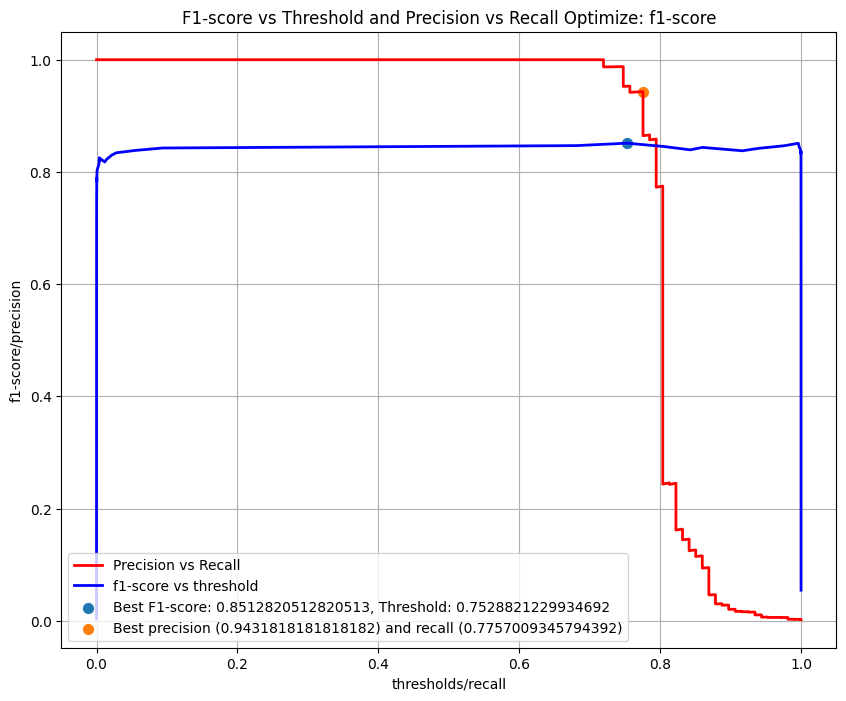

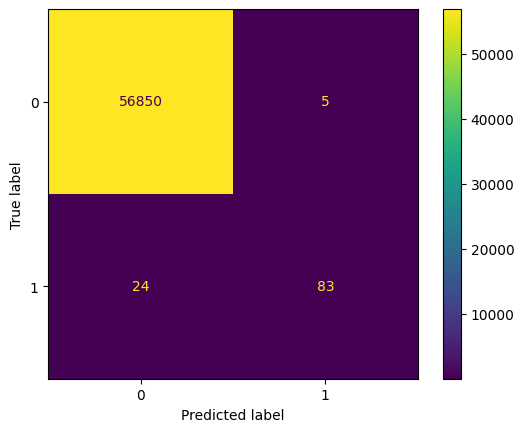

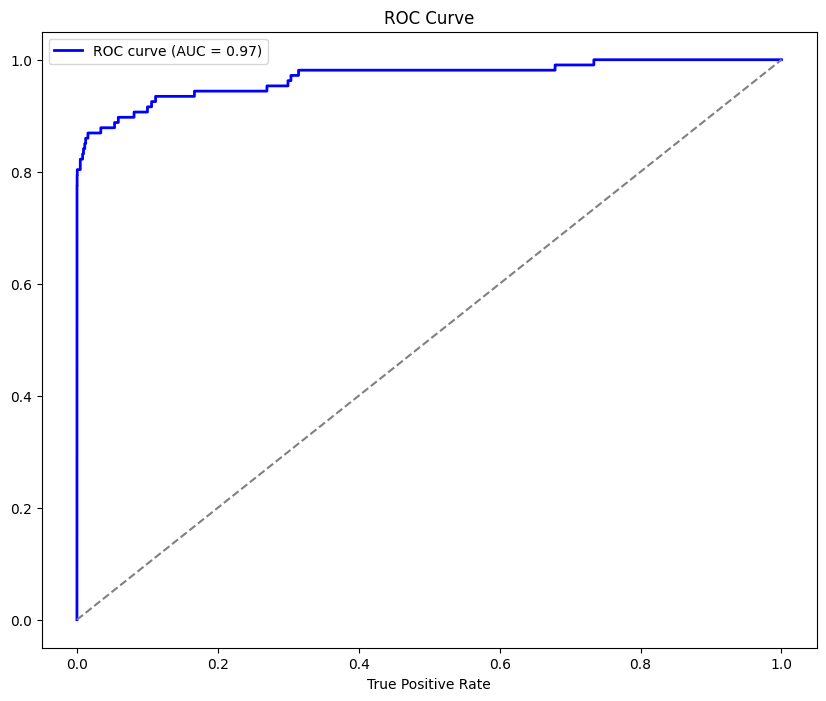

In [114]:
model_gradient.summary()
model_gradient.compile(metrics=['accuracy'])
evaluation = model_gradient.evaluate(test_ds, return_dict=True, use_multiprocessing=True)
preds = model_gradient.predict(test_ds)
print(f"The RMSE of this testing evaluation is: {evaluation}")

inspector = model_gradient.make_inspector()
print(inspector.evaluation())
print(inspector.variable_importances())
print_graphs(y_test, preds)
fpr, tpr, thresholds = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

Now use the subset up to Time that we found

Use 12 thread(s) for training
Use /tmp/tmp87vv0zar as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'V17': <tf.Tensor 'data:0' shape=(None,) dtype=float64>, 'V12': <tf.Tensor 'data_1:0' shape=(None,) dtype=float64>, 'V4': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'V14': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'V10': <tf.Tensor 'data_4:0' shape=(None,) dtype=float64>, 'V21': <tf.Tensor 'data_5:0' shape=(None,) dtype=float64>}
Label: Tensor("data_6:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'V17': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(None,) dtype=float32>), 'V12': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_1:0' shape=(None,) dtype=float32>), 'V4': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_2:0' shape=(None,) dtype=float32>), 'V14': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, te

W0000 00:00:1766022003.300285  108164 gradient_boosted_trees.cc:1873] "goss_alpha" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1766022003.300314  108164 gradient_boosted_trees.cc:1883] "goss_beta" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1766022003.300317  108164 gradient_boosted_trees.cc:1897] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:00:00.587794. Found 227845 examples.
Training model...
Model trained in 0:00:01.661239
Compiling model...
Model compiled.
Model: "gradient_boosted_trees_model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (6):
	V10
	V12
	V14
	V17
	V21
	V4

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1. "V17"  0.577486 ################
    2. "V14"  0.359177 ######
    3. "V10"  0.225606 #
    4.  "V4"  0.221537 
    5. "V12"  0.206631 
    6. "V21"  0.202088 

Variable Importance: NUM_AS_ROOT:
    1. "V17" 36.000000 ################
    2. "V10"  6.000000 
    3. "V14"  6.000000 

Variable Importance: NUM_NODES:
    1. "V17" 246.0000

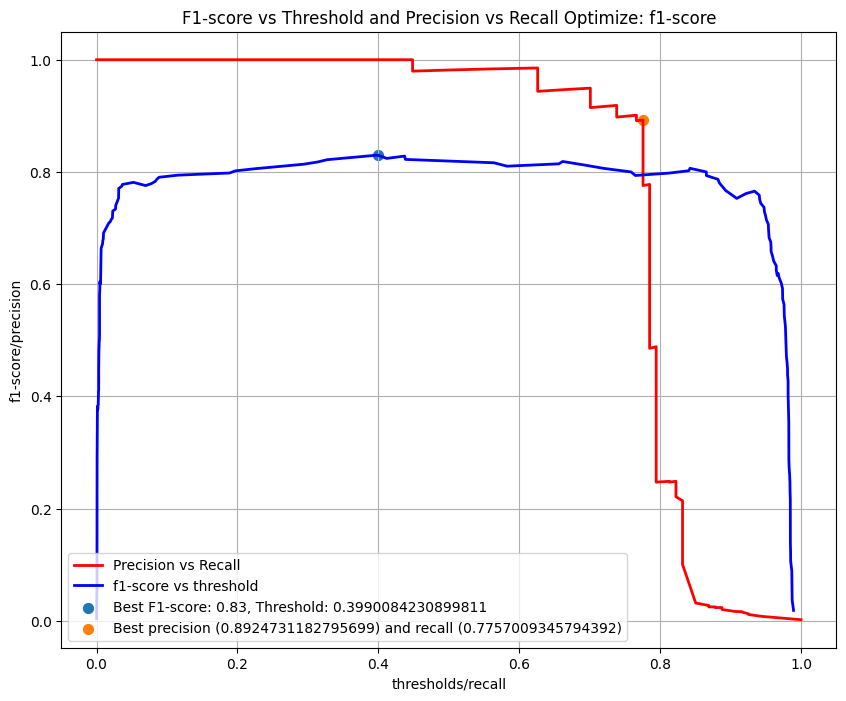

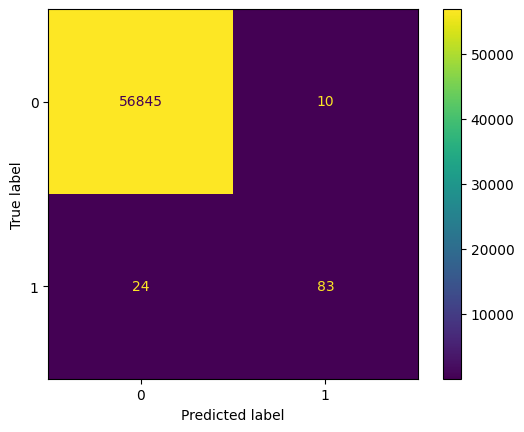

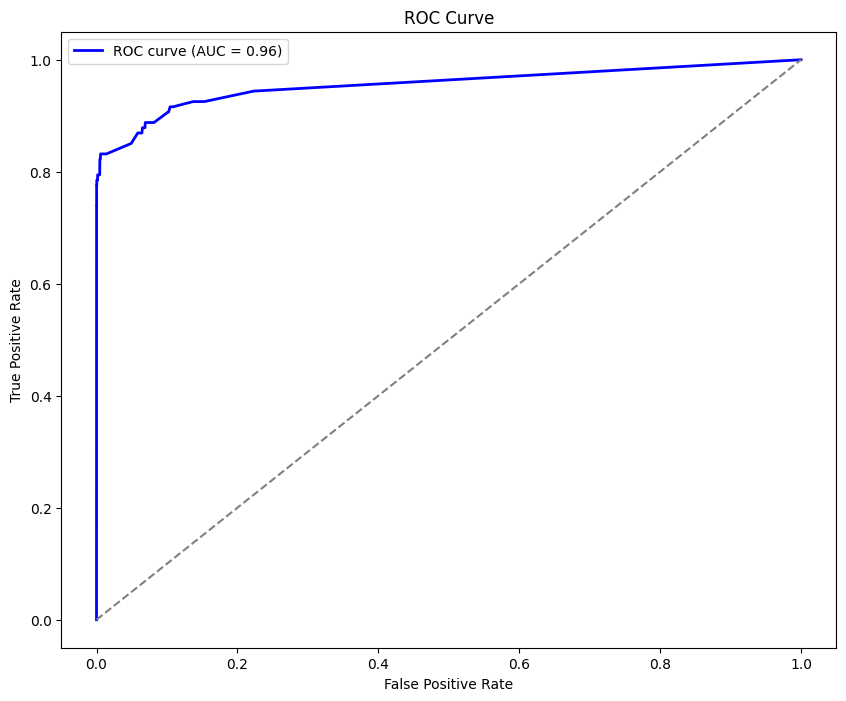

In [82]:
model_gradient = tfdf.keras.GradientBoostedTreesModel(task=tfdf.keras.Task.CLASSIFICATION, verbose=2, random_seed = 67)
model_gradient.fit(one_train_ds)

model_gradient.summary()
model_gradient.compile(metrics=['accuracy'])
evaluation = model_gradient.evaluate(test_ds, return_dict=True, use_multiprocessing=True)
preds = model_gradient.predict(one_test_ds)


print(f"The RMSE of this testing evaluation is: {evaluation}")

inspector = model_gradient.make_inspector()
print(inspector.evaluation())
print(inspector.variable_importances())
print_graphs(y_test, preds)
fpr, tpr, thresholds = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

## This already as a 99.94% accuracy for the testing data. We can try a logistic regression to compare using all predictors.

Train Accuracy: 0.9988720402027694
Test Accuracy: 0.9988588883817282


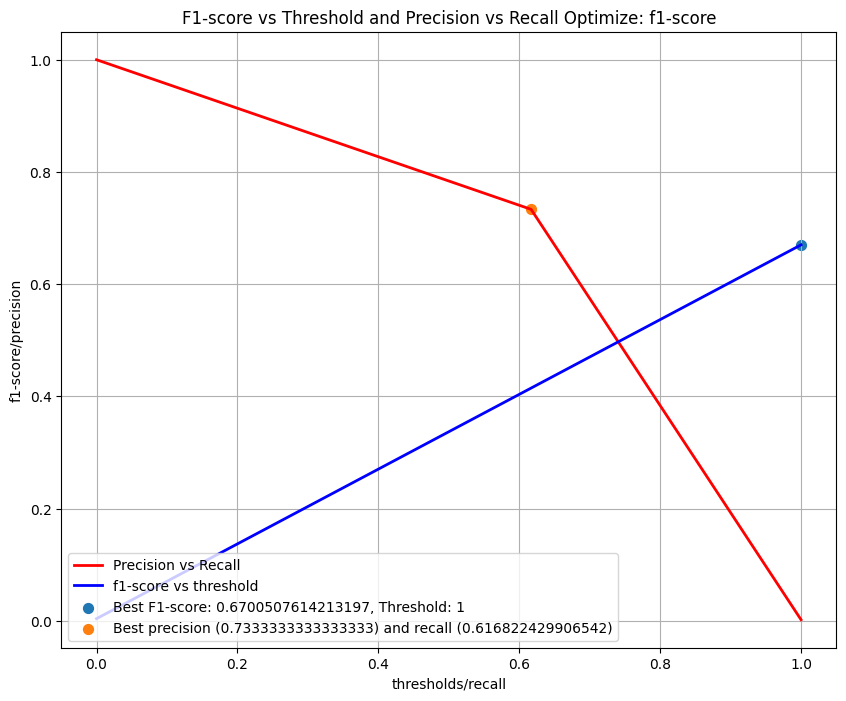

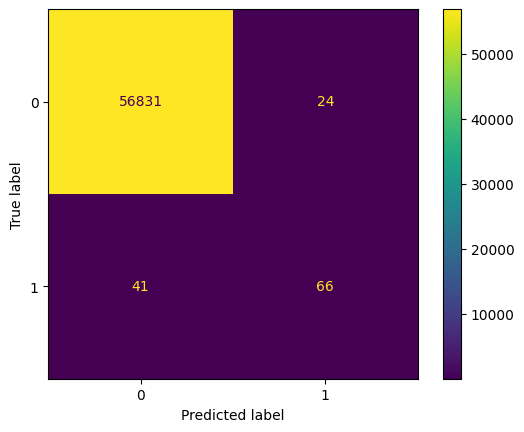

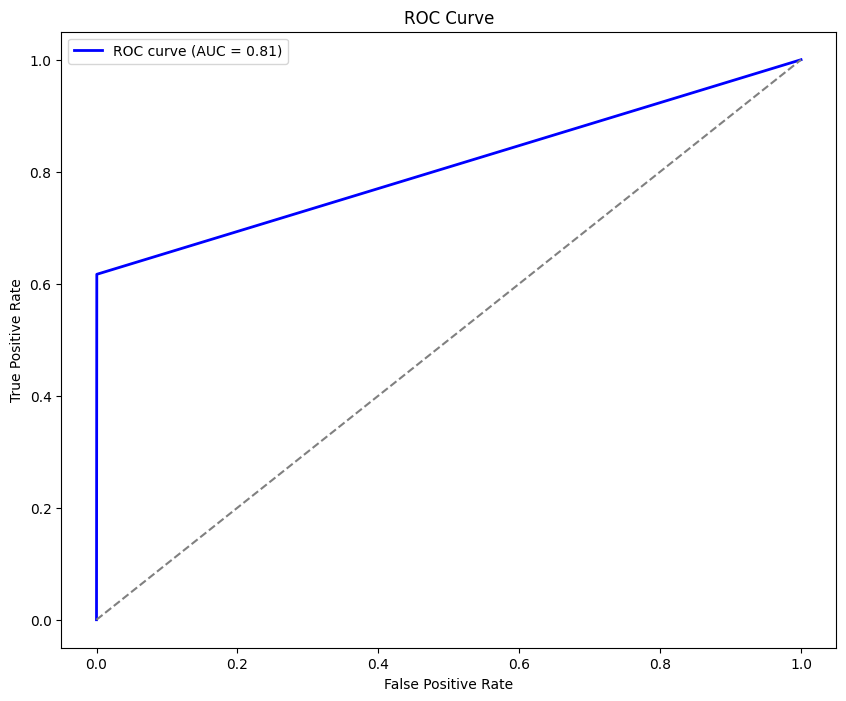

In [83]:
logisticFit = LogisticRegression(solver="liblinear", penalty="l2", random_state=67)
logisticFit.fit(x_train.drop(columns=["Class"]), y_train)

pred_train = logisticFit.predict(x_train.drop(columns=["Class"]))
pred_test = logisticFit.predict(x_test.drop(columns=["Class"]))

pred_train_score = accuracy_score(y_train, pred_train)
pred_test_score = accuracy_score(y_test, pred_test)

print(f"Train Accuracy: {pred_train_score}")
print(f"Test Accuracy: {pred_test_score}")

print_graphs(y_test, pred_test)
fpr, tpr, thresholds = roc_curve(y_test, pred_test)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

Try To find the best subset when using logistic regression

In [14]:
subset_selection_log = []
val_accuracy_log = []
remain_feature_log = list(df.columns.drop('Class'))
best_val_accuracy_log = 0
n = len(remain_feature_log)
print(remain_feature_log)
a = 0
for i in range(n):
    print(a)
    vals = {}
    for feature in remain_feature_log:
        subset = subset_selection_log.copy() + [feature]
        sub_x_train, sub_x_val, sub_y_train, sub_y_val = train_test_split(x_train[subset], y_train, test_size=.2, random_state=376)
        

        logisticFit = LogisticRegression(solver="liblinear", penalty="l2", random_state=67)
        logisticFit.fit(sub_x_train, sub_y_train)


        pred_test = logisticFit.predict(sub_x_val)


        vals[feature] = accuracy_score(sub_y_val, pred_test)
        
    best_sub_val = max(vals.values())
    best_feature = [key for key, item in vals.items() if item == best_sub_val][0]
    subset_selection_log.append(best_feature)
    val_accuracy_log.append(best_sub_val)
    remain_feature_log.remove(best_feature)
    a = a +1

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [15]:
print(subset_selection_log)
print(val_accuracy_log)

['V14', 'V12', 'V4', 'V22', 'V1', 'V16', 'V3', 'V10', 'V13', 'V11', 'V17', 'V15', 'V18', 'V19', 'V23', 'V21', 'V26', 'V9', 'V6', 'V24', 'V25', 'V27', 'V28', 'Amount', 'V7', 'V2', 'V8', 'V5', 'V20', 'Time']
[0.9987491496412034, 0.999100265531392, 0.9991441550176655, 0.9991660997608023, 0.9991660997608023, 0.999188044503939, 0.999188044503939, 0.9992099892470758, 0.9992319339902126, 0.9992538787333495, 0.9992758234764862, 0.9992758234764862, 0.9992758234764862, 0.9992758234764862, 0.9992758234764862, 0.9992758234764862, 0.999297768219623, 0.9992758234764862, 0.9992758234764862, 0.9992538787333495, 0.9992099892470758, 0.999188044503939, 0.999188044503939, 0.999188044503939, 0.9991660997608023, 0.9991222102745287, 0.9991660997608023, 0.9991660997608023, 0.9991441550176655, 0.9989027628431609]


Use first 7 of subset the same as the one found for the Random Forest

Test Accuracy: 0.9991573329588147


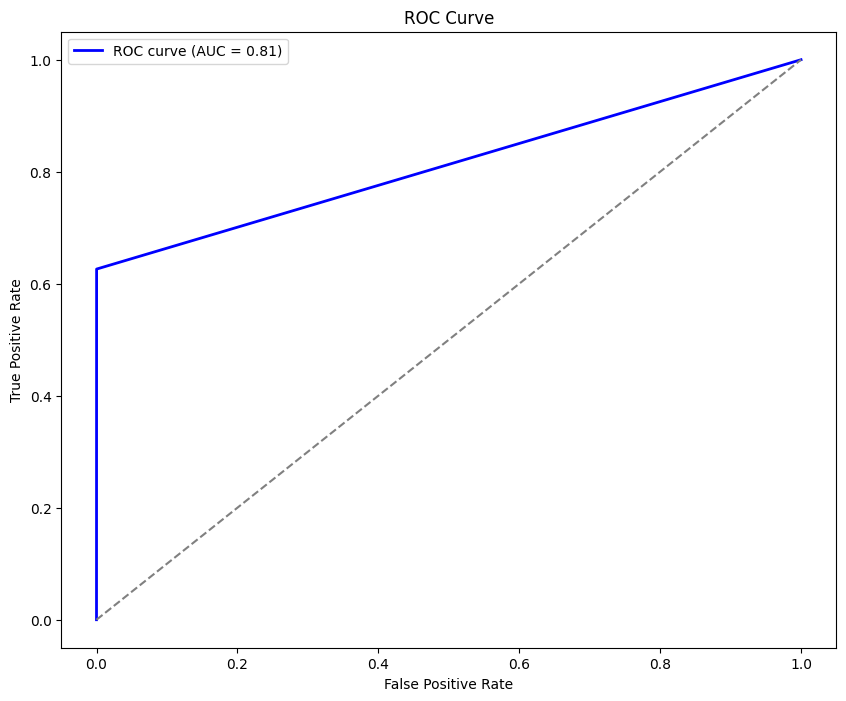

In [20]:
subset_log = subset_selection_log[0:7]
one_x_train_log = x_train[subset_log].copy()
one_x_test_log = x_test[subset_log].copy()


model_subset_log = LogisticRegression(solver="liblinear", penalty="l2", random_state=67)
model_subset_log.fit(one_x_train_log, y_train)


pred_test_log = model_subset_log.predict(one_x_test_log)
pred_test_score = accuracy_score(y_test, pred_test_log)
print(f"Test Accuracy: {pred_test_score}")
fpr, tpr, thresholds = roc_curve(y_test, pred_test_log)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()